In [1]:
library(mgcv)
# library(gratia)
library(ggplot2)
library(patchwork)

library(dplyr)

Loading required package: nlme

This is mgcv 1.9-4. For overview type '?mgcv'.


Attaching package: ‘dplyr’


The following object is masked from ‘package:nlme’:

    collapse


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
data_path = '/home/hmbaghda/orcd/pool/scLEMBAS/analysis'
author = 'Kang'

c_fn = file.path(data_path, 'processed', 'Kang_de_concordance.csv')

In [3]:
df <- read.csv(c_fn, check.names = FALSE)

# drop pandas index column if present
if (names(df)[1] %in% c("X", "Unnamed: 0", "")) {
  df <- df[, -1, drop = FALSE]
}

id_vars <- c("direction", "test_condition", "mod_type", "rank")

# sanity check
missing <- setdiff(id_vars, names(df))
if (length(missing) > 0) stop(paste("Missing expected columns:", paste(missing, collapse=", ")))

measure_vars <- setdiff(names(df), id_vars)

# stack wide -> long values
st <- stack(df[measure_vars])  # st$values, st$ind (column names)

# repeat id rows for each measure column
id_rep <- df[rep(seq_len(nrow(df)), times = length(measure_vars)), id_vars, drop = FALSE]

concordance_df <- cbind(
  id_rep,
  subsample_iteration = st$ind,
  jaccard_index = st$values
)

# pandas notna()
concordance_df <- concordance_df[!is.na(concordance_df$jaccard_index), ]
rownames(concordance_df) <- NULL

Because many subsamples, particularly for the baseline, don't have many DE features, we limit this analysis to top features using a heuristic threshold. The no adversarial baseline has a steep elbow at 70 features, so we threshold to a rank of 50 and better. 

Note, results are qualitatively the same when using all feature ranks.

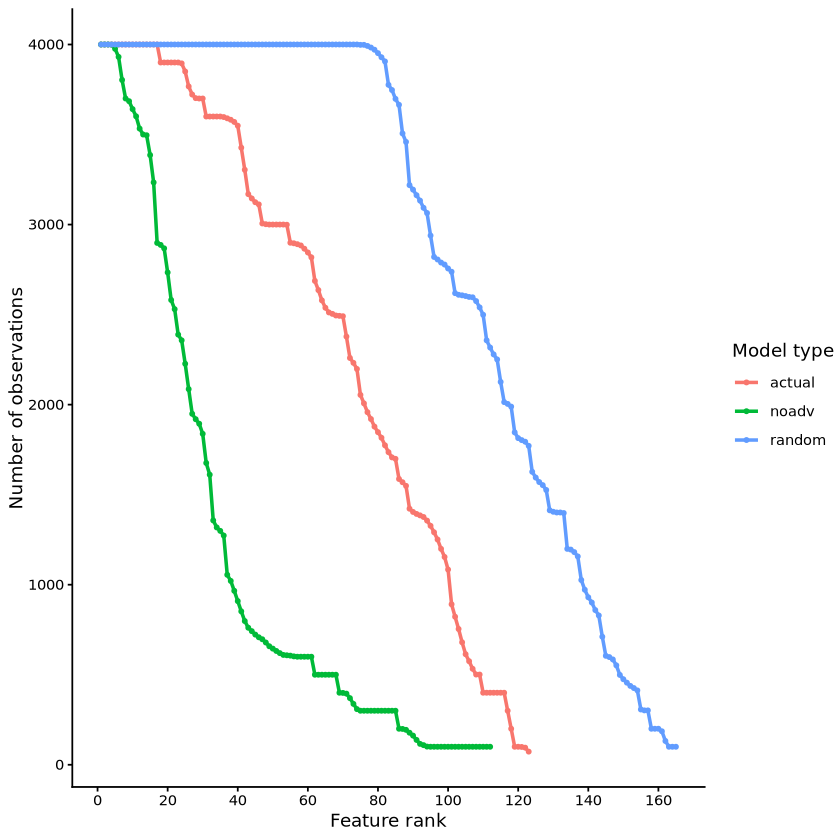

In [4]:
rank_mod_counts_df <- concordance_df %>%
  count(mod_type, rank, name = "count") %>%   # only observed combos
  mutate(rank = as.numeric(rank)) %>%
  arrange(mod_type, rank)

ggplot(rank_mod_counts_df, aes(x = rank, y = count, color = mod_type)) +
  geom_line(linewidth = 1) +
  geom_point(size = 1) +
  scale_x_continuous(breaks = scales::pretty_breaks(n = 10)) +
  labs(
    x = "Feature rank",
    y = "Number of observations",
    color = "Model type"
  ) +
  theme_classic()

In [5]:
concordance_df <- subset(concordance_df, rank <= 50)

Fit the GAMM. mod_type is included as a fixed effect (intercept) and varying with rank so each has its own curve.

In [6]:
concordance_df$mod_type <- factor(concordance_df$mod_type,
                                  levels = c("actual", "random", "noadv"))

concordance_df$direction <- factor(concordance_df$direction)
concordance_df$test_condition <- factor(concordance_df$test_condition)
concordance_df$subsample_iteration <- factor(concordance_df$subsample_iteration)

In [7]:
model <- bam(
  jaccard_index ~ 
    mod_type + direction +
    s(rank, by = mod_type, k = 5) +
    s(test_condition, bs = "re") +
    s(subsample_iteration, bs = "re"),
  data = concordance_df,
  method = "fREML",    #fast REML for bam()
  discrete = TRUE,     # Discretizes covariates for speed
  nthreads = 15         # Use multiple cores (adjust to your machine)
)


In [8]:
summary(model)


Family: gaussian 
Link function: identity 

Formula:
jaccard_index ~ mod_type + direction + s(rank, by = mod_type, 
    k = 5) + s(test_condition, bs = "re") + s(subsample_iteration, 
    bs = "re")

Parametric coefficients:
                    Estimate Std. Error t value Pr(>|t|)    
(Intercept)        0.3117922  0.0079481   39.23   <2e-16 ***
mod_typerandom    -0.1976258  0.0004598 -429.77   <2e-16 ***
mod_typenoadv     -0.1398809  0.0006169 -226.76   <2e-16 ***
directionpositive -0.0502205  0.0004041 -124.27   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Approximate significance of smooth terms:
                             edf Ref.df    F p-value    
s(rank):mod_typeactual  3.992269  4.000 3630  <2e-16 ***
s(rank):mod_typerandom  3.918980  3.996 1830  <2e-16 ***
s(rank):mod_typenoadv   3.986319  4.000 2274  <2e-16 ***
s(test_condition)      18.987469 19.000 1582  <2e-16 ***
s(subsample_iteration)  0.003815 99.000    0       1    
---
Signif. codes


Method: fREML   Optimizer: perf chol
$grad
[1]  5.903629e-06 -1.243450e-14  4.237277e-07 -4.589396e-11 -1.845657e-03
[6] -6.383430e-06

$hess
           [,1]          [,2]          [,3]          [,4]          [,5]
   1.491220e+00 -2.320517e-21 -1.290160e-06 -1.385800e-05  8.750822e-10
   2.190994e-21  1.327668e+00  5.415679e-23  1.834402e-20 -9.944624e-24
  -1.290160e-06 -7.998674e-22  1.494255e+00  2.528600e-05 -2.008753e-10
  -1.385800e-05 -2.387302e-20  2.528600e-05  9.487758e+00 -1.677845e-11
   8.750822e-10 -9.682211e-25 -2.008753e-10 -1.677845e-11  1.845588e-03
d -1.496140e+00 -1.459490e+00 -1.493160e+00 -9.493734e+00 -6.172656e-05
           [,6]
  -1.496140e+00
  -1.459490e+00
  -1.493160e+00
  -9.493734e+00
  -6.172656e-05
d  2.486480e+05

Model rank =  136 / 136 

Basis dimension (k) checking results. Low p-value (k-index<1) may
indicate that k is too low, especially if edf is close to k'.

                             k'      edf k-index p-value    
s(rank):mod_typeactual 4

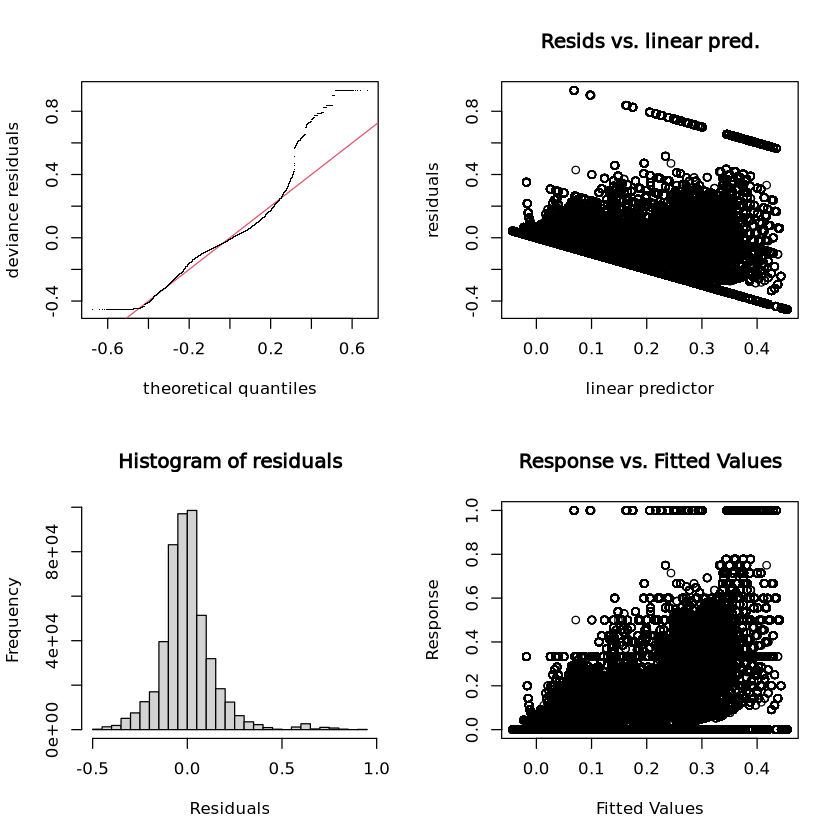

In [9]:
par(mfrow=c(2,2))
gam.check(model)

cat("\nChecking for concurvity (similar to multicollinearity):\n")
print(concurvity(model, full=FALSE))
cat("\nValues close to 1 indicate problematic concurvity.\n")
cat("Values < 0.8 are generally acceptable.\n")

Get the statistics. We are asking: Does the actual model have significantly higher concordance than the baselines across feature ranks?

Methodologically: Rank-wise performance differences between model types were estimated using contrasts of full fitted values from a generalized additive mixed model. For each feature rank, predicted concordance differences between models were computed using the model’s parametric and smooth components and marginalized over effect-direction by averaging across direction levels using empirical weights. Pointwise 95% Wald confidence intervals were obtained from the model coefficient covariance matrix. To obtain population-level comparisons, random-effect smooths for test condition and subsampling were excluded from the contrasts.

In [10]:
#' Contrast full fitted curves between two mod_type levels across rank,
#' marginalized over direction
#'
#' Computes Δ(rank) = E_direction[ y_hat(level_1, rank) - y_hat(level_2, rank) ]
#' using the full fitted model (parametric + smooths). Marginalization is performed
#' by averaging the model-based contrasts across all levels of `direction` using either
#' empirical (observed) or equal weights. Pointwise Wald confidence intervals are
#' computed from the model coefficient covariance matrix. Optionally excludes
#' random-effect smooths (e.g., s(test_condition), s(subsample_iteration)) to yield
#' population-level comparisons.
#'
#' @param model A fitted mgcv::gam/bam object.
#' @param data The original data.frame used to fit the model (needed for levels and defaults).
#' @param level_1 First mod_type level (e.g. "actual").
#' @param level_2 Second mod_type level (e.g. "random" or "noadv").
#' @param rank_var Name of the rank variable (default "rank").
#' @param mod_var Name of the model-type variable (default "mod_type").
#' @param dir_var Name of the direction variable to marginalize over (default "direction").
#' @param n Number of grid points over rank (default 200).
#' @param ci_level Confidence level for pointwise CI (default 0.95).
#' @param weights Weighting scheme for marginalization over direction: "empirical"
#'        (observed direction frequencies in `data`) or "equal" (uniform over direction levels).
#' @param exclude_terms Character vector of smooth term labels to exclude (e.g. random effects).
#'        Default excludes s(test_condition) and s(subsample_iteration) if present.
#' @param hold_list Named list of other covariates (besides rank/mod_type/direction) to hold fixed
#'        in `newdata`. If NULL, uses sensible defaults (first factor level / median numeric).
#'
#' @return A data.frame with columns: rank, diff, se, lower, upper, comparison, sig
contrast_rank_full_marginal_direction <- function(model,
                                                  data,
                                                  level_1,
                                                  level_2,
                                                  rank_var = "rank",
                                                  mod_var  = "mod_type",
                                                  dir_var  = "direction",
                                                  n = 200,
                                                  ci_level = 0.95,
                                                  weights = c("empirical", "equal"),
                                                  exclude_terms = NULL,
                                                  hold_list = NULL) {
  stopifnot(is.data.frame(data))
  weights <- match.arg(weights)

  # Ensure factors & levels
  data[[mod_var]] <- factor(data[[mod_var]])
  data[[dir_var]] <- factor(data[[dir_var]])
  lev_mod <- levels(data[[mod_var]])
  lev_dir <- levels(data[[dir_var]])
  if (!(level_1 %in% lev_mod) || !(level_2 %in% lev_mod)) {
    stop(sprintf("Levels not found in %s. Levels are: %s",
                 mod_var, paste(lev_mod, collapse = ", ")))
  }

  # Default exclude random-effect smooths if present
  if (is.null(exclude_terms)) {
    sm_labs <- tryCatch(mgcv::smooths(model), error = function(e) character())
    cand <- c("s(test_condition)", "s(subsample_iteration)")
    exclude_terms <- cand[cand %in% sm_labs]
  }

  # Direction weights
  w_dir <- if (weights == "empirical") {
    prop.table(table(data[[dir_var]]))[lev_dir] |> as.numeric()
  } else {
    rep(1/length(lev_dir), length(lev_dir))
  }
  names(w_dir) <- lev_dir

  # Rank grid
  rmin <- min(data[[rank_var]], na.rm = TRUE)
  rmax <- max(data[[rank_var]], na.rm = TRUE)
  rank_grid <- seq(rmin, rmax, length.out = n)

  # Defaults for other covariates (held values)
  exclude_names <- c(rank_var, mod_var, dir_var)

  make_default_hold <- function(df, exclude_names) {
    out <- list()
    for (nm in setdiff(names(df), exclude_names)) {
      x <- df[[nm]]
      if (is.factor(x)) out[[nm]] <- levels(x)[1]
      else if (is.character(x)) out[[nm]] <- sort(unique(x))[1]
      else if (is.numeric(x) || is.integer(x)) out[[nm]] <- stats::median(x, na.rm = TRUE)
      else out[[nm]] <- x[which(!is.na(x))[1]]
    }
    out
  }

  hold_defaults <- make_default_hold(data, exclude_names)
  if (!is.null(hold_list)) hold_defaults[names(hold_list)] <- hold_list

  # Base newdata with held covariates
  base <- data.frame(rank = rank_grid)
  names(base)[1] <- rank_var

  for (nm in names(hold_defaults)) {
    if (!nm %in% names(data)) next
    val <- hold_defaults[[nm]]
    if (is.factor(data[[nm]])) base[[nm]] <- factor(val, levels = levels(data[[nm]]))
    else if (is.integer(data[[nm]])) base[[nm]] <- as.integer(val)
    else if (is.numeric(data[[nm]])) base[[nm]] <- as.numeric(val)
    else base[[nm]] <- val
  }

  # Build weighted contrast lpmatrix across directions:
  # Xd_bar = sum_d w_d * (X1_d - X2_d)
  Xd_bar <- NULL
  for (d in lev_dir) {
    nd1 <- base
    nd2 <- base
    nd1[[mod_var]] <- factor(level_1, levels = lev_mod)
    nd2[[mod_var]] <- factor(level_2, levels = lev_mod)
    nd1[[dir_var]] <- factor(d, levels = lev_dir)
    nd2[[dir_var]] <- factor(d, levels = lev_dir)

    X1 <- mgcv::predict.gam(model, newdata = nd1, type = "lpmatrix", exclude = exclude_terms)
    X2 <- mgcv::predict.gam(model, newdata = nd2, type = "lpmatrix", exclude = exclude_terms)
    Xd <- (X1 - X2) * w_dir[d]

    Xd_bar <- if (is.null(Xd_bar)) Xd else (Xd_bar + Xd)
  }

  beta <- stats::coef(model)
  V <- stats::vcov(model)

  diff_hat <- drop(Xd_bar %*% beta)
  se_hat <- sqrt(rowSums((Xd_bar %*% V) * Xd_bar))

  alpha <- 1 - ci_level
  z <- stats::qnorm(1 - alpha/2)

  lower <- diff_hat - z * se_hat
  upper <- diff_hat + z * se_hat

  out <- data.frame(
    rank = rank_grid,
    diff = diff_hat,
    se = se_hat,
    lower = lower,
    upper = upper,
    comparison = paste0(level_1, " - ", level_2, " (marginalized over ", dir_var, ")"),
    stringsAsFactors = FALSE
  )

  out$sig <- ifelse(out$lower > 0, paste0(level_1, " > ", level_2),
                    ifelse(out$upper < 0, paste0(level_1, " < ", level_2),
                           "Not significant"))
  out
}

In [11]:
diff_AR <- contrast_rank_full_marginal_direction(
  model, concordance_df, "actual", "random",
  weights = "empirical",
  exclude_terms = c("s(test_condition)", "s(subsample_iteration)")
)

diff_AN <- contrast_rank_full_marginal_direction(
  model, concordance_df, "actual", "noadv",
  weights = "empirical",
  exclude_terms = c("s(test_condition)", "s(subsample_iteration)")
)

Quantitate: Point-wise across ranks, how frequently did the actual model outperform the baselines?

In [12]:
prop_AR_pos <- mean(diff_AR$sig == "actual > random")
prop_AR_neg <- mean(diff_AR$sig == "actual < random")
prop_AR_ns  <- mean(diff_AR$sig == "Not significant")

prop_AN_pos <- mean(diff_AN$sig == "actual > noadv")
prop_AN_neg <- mean(diff_AN$sig == "actual < noadv")
prop_AN_ns  <- mean(diff_AN$sig == "Not significant")

cat("Actual vs Random (marginalized over direction):\n")
cat(sprintf("  Actual > Random:     %.2f\n", prop_AR_pos))
cat(sprintf("  Actual < Random:     %.2f\n", prop_AR_neg))
cat(sprintf("  Not significant:     %.2f\n\n", prop_AR_ns))

cat("Actual vs NoAdversarial (marginalized over direction):\n")
cat(sprintf("  Actual > NoAdv:      %.2f\n", prop_AN_pos))
cat(sprintf("  Actual < NoAdv:      %.2f\n", prop_AN_neg))
cat(sprintf("  Not significant:     %.2f\n", prop_AN_ns))

Actual vs Random (marginalized over direction):
  Actual > Random:     1.00
  Actual < Random:     0.00
  Not significant:     0.00

Actual vs NoAdversarial (marginalized over direction):
  Actual > NoAdv:      1.00
  Actual < NoAdv:      0.00
  Not significant:     0.00


At all point-wise ranks, the actual model has significantly higher concordance than the baselines. 

Quantitate: When you average over ranks, accounting for how large the differences are, which model is better overall?

Methodologically: Global performance differences across feature ranks were summarized using a mean normalized area-under-the-curve (nAUC) metric. Specifically, the fitted rank-wise contrast between models was numerically integrated using the trapezoidal rule and normalized by the rank range, yielding the average fitted concordance difference across ranks. Positive nAUC values indicate that the Actual model exhibits higher fitted concordance than the baseline on average across feature ranks.

In [13]:
# auc_diff <- function(df) {
#   ord <- order(df$rank)
#   x <- df$rank[ord]
#   y <- df$diff[ord]   # <-- note: diff, not .diff
#   sum(diff(x) * (head(y, -1) + tail(y, -1)) / 2)
# }

# obs_auc_AR <- auc_diff(diff_AR)
# obs_auc_AN <- auc_diff(diff_AN)

# cat("\nIntegrated fitted-difference (AUC):\n\n")
# cat(sprintf("Actual − Random:        %.4f\n", obs_auc_AR))
# cat(sprintf("Actual − NoAdversarial: %.4f\n", obs_auc_AN))

# cat("\nInterpretation:\n")
# cat("  AUC > 0  → Actual model globally outperforms baseline\n")
# cat("  AUC < 0  → Baseline globally outperforms Actual\n")


nauc_mean <- function(df) {
  ord <- order(df$rank)
  x <- df$rank[ord]
  y <- df$diff[ord]
  auc <- sum(diff(x) * (head(y, -1) + tail(y, -1)) / 2)
  auc / (max(x) - min(x))
}

nauc_AR <- nauc_mean(diff_AR)
nauc_AN <- nauc_mean(diff_AN)

cat("\nMean fitted-difference across ranks (nAUC):\n\n")
cat(sprintf("Actual − Random:        %.4f\n", nauc_AR))
cat(sprintf("Actual − NoAdversarial: %.4f\n", nauc_AN))

cat("\nInterpretation:\n")
cat("  nAUC represents the average fitted concordance difference across feature ranks.\n")
cat("  For example, nAUC = 0.02 means the Actual model exceeds the baseline by ~0.02\n")
cat("  in fitted concordance on average across ranks.\n")




# cat("\nIntegrated fitted-difference (AUC):\n\n")
# cat(sprintf("Actual − Random:        %.4f\n", nauc_AR))
# cat(sprintf("Actual − NoAdversarial: %.4f\n", nauc_AN))

# cat("\nInterpretation:\n")
# cat("  nAUC > 0  → On average across feature ranks, the Actual model exhibits higher fitted concordance than the baseline\n")
# cat("  nAUC < 0  → On average across feature ranks, the baseline exhibits higher fitted concordance than the Actual model\n")


Mean fitted-difference across ranks (nAUC):

Actual − Random:        0.1945
Actual − NoAdversarial: 0.1400

Interpretation:
  nAUC represents the average fitted concordance difference across feature ranks.
  For example, nAUC = 0.02 means the Actual model exceeds the baseline by ~0.02
  in fitted concordance on average across ranks.


Visualize the smooth curve differences:

In [14]:
theme_pub_bw <- function(base_size = 11,
                         base_family = "",
                         show_legend = FALSE) {

  theme_bw(base_size = base_size, base_family = base_family) +
    theme(
      # remove distracting minor grid; keep faint major grid if you like
      panel.grid.minor = element_blank(),
      panel.grid.major = element_line(linewidth = 0.25),

      # crisp panel border
      panel.border = element_rect(linewidth = 0.6),

      # ticks & axis text
      axis.ticks = element_line(linewidth = 0.5),
      axis.ticks.length = unit(2, "pt"),
      axis.title = element_text(size = base_size),
      axis.text  = element_text(size = base_size - 1),

      # titles
      plot.title = element_text(hjust = 0.5, face = "bold", size = base_size),

      # consistent spacing
      plot.margin = margin(6, 6, 6, 6),

      # optional legend
      legend.position = if (show_legend) "right" else "none"
    )
}

Ignoring unknown labels:
• colour : ""
Ignoring unknown labels:
• colour : ""
Ignoring unknown labels:
• colour : ""
Ignoring unknown labels:
• colour : ""


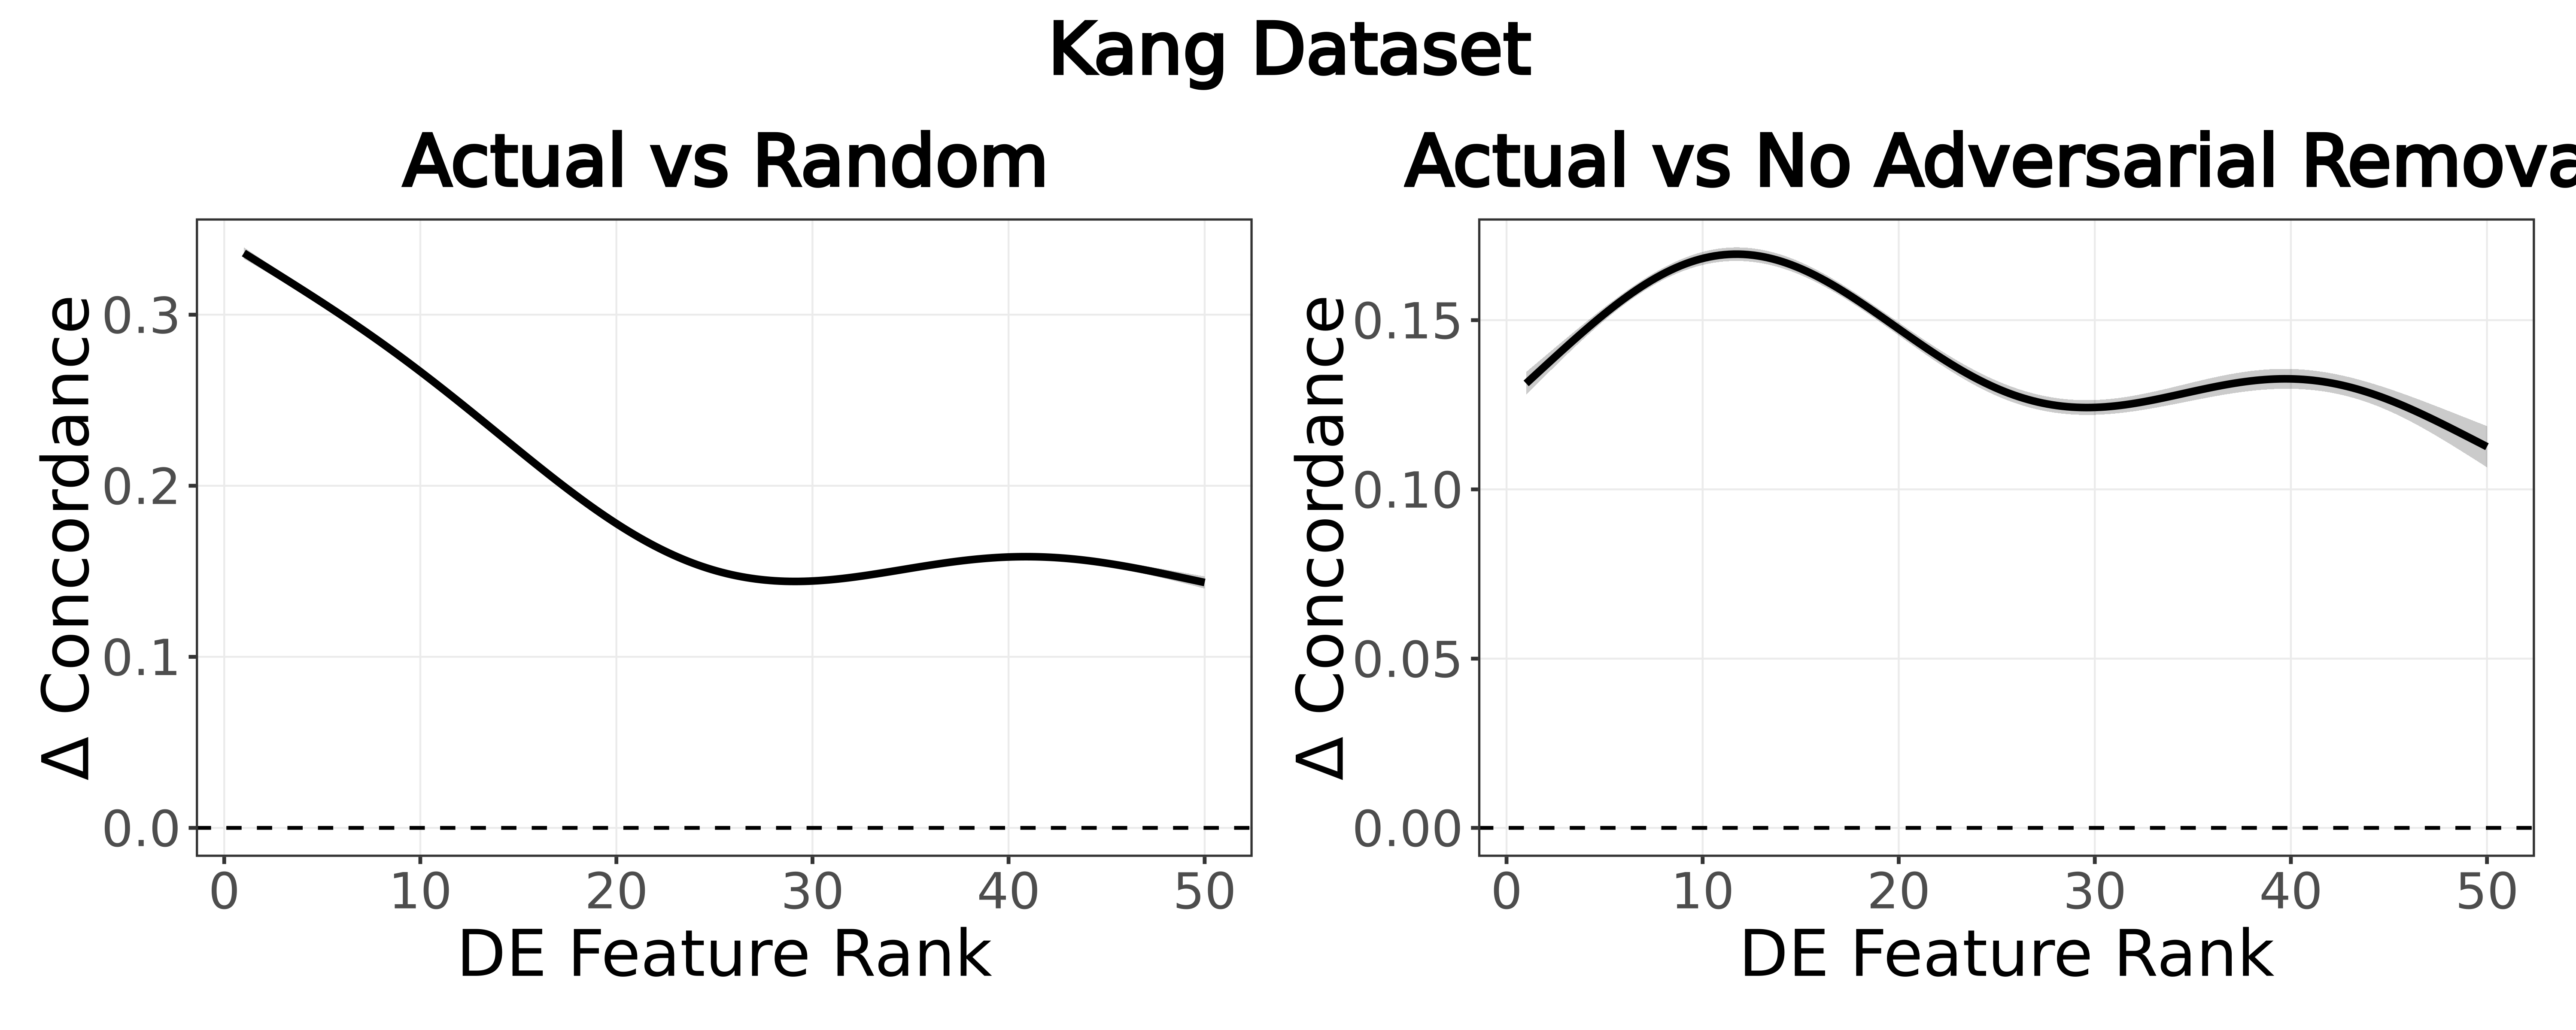

In [26]:
h = 4
w = 10
options(
  repr.plot.width  = w,
  repr.plot.height = h
)

# Shared theme tweaks to match the McCauley plot's aesthetics
common_theme <- theme(
  legend.position = "none",
  axis.text       = element_text(size = 14),
  axis.title      = element_text(size = 18),
  plot.title      = element_text(size = 20, face = "bold", hjust = 0.5)
)

p_AR <- ggplot(diff_AR, aes(x = rank, y = diff)) +
  geom_ribbon(
    aes(ymin = lower, ymax = upper),
    alpha = 0.25
  ) +
  geom_line(linewidth = 1) +                 # single continuous fitted contrast
#   geom_point(aes(color = sig), size = 2) +   # significance at each rank
  geom_hline(yintercept = 0, linetype = "dashed") +
#   scale_color_manual(
#     values = c(
#       "actual > random" = "#1b9e77",
#       "actual < random" = "#d95f02",
#       "Not significant" = "grey40"
#     )
#   ) +
  labs(
    x = "DE Feature Rank",
    y = "Δ Concordance",
    color = ""
  ) + ggtitle("Actual vs Random") + 
  theme_pub_bw() + common_theme


p_AN <- ggplot(diff_AN, aes(x = rank, y = diff)) +
  geom_ribbon(
    aes(ymin = lower, ymax = upper),
    alpha = 0.25
  ) +
  geom_line(linewidth = 1) +                 # single continuous fitted contrast
#   geom_point(aes(color = sig), size = 2) +   # significance at each rank
  geom_hline(yintercept = 0, linetype = "dashed") +
#   scale_color_manual(
#     values = c(
#       "actual > noadv" = "#1b9e77",
#       "actual < noadv" = "#d95f02",
#       "Not significant" = "grey40"
#     )
#   ) +
  labs(
    x = "DE Feature Rank",
    y = "Δ Concordance",
    color = ""
  ) + ggtitle("Actual vs No Adversarial Removal") + 
  theme_pub_bw() + common_theme

p_both <- (p_AR | p_AN) +
  plot_annotation(
    title = "Kang Dataset",
    theme = theme(
      plot.title = element_text(size = 20, face = "bold", hjust = 0.5)
    )
  )

p_both

ggsave(
  file.path(data_path, 'figures', 'Kang_GAM_delta.png'),
  plot = p_both,
  width = w,
  height = h,
  units = "in"
)


Visualize the partial effect:

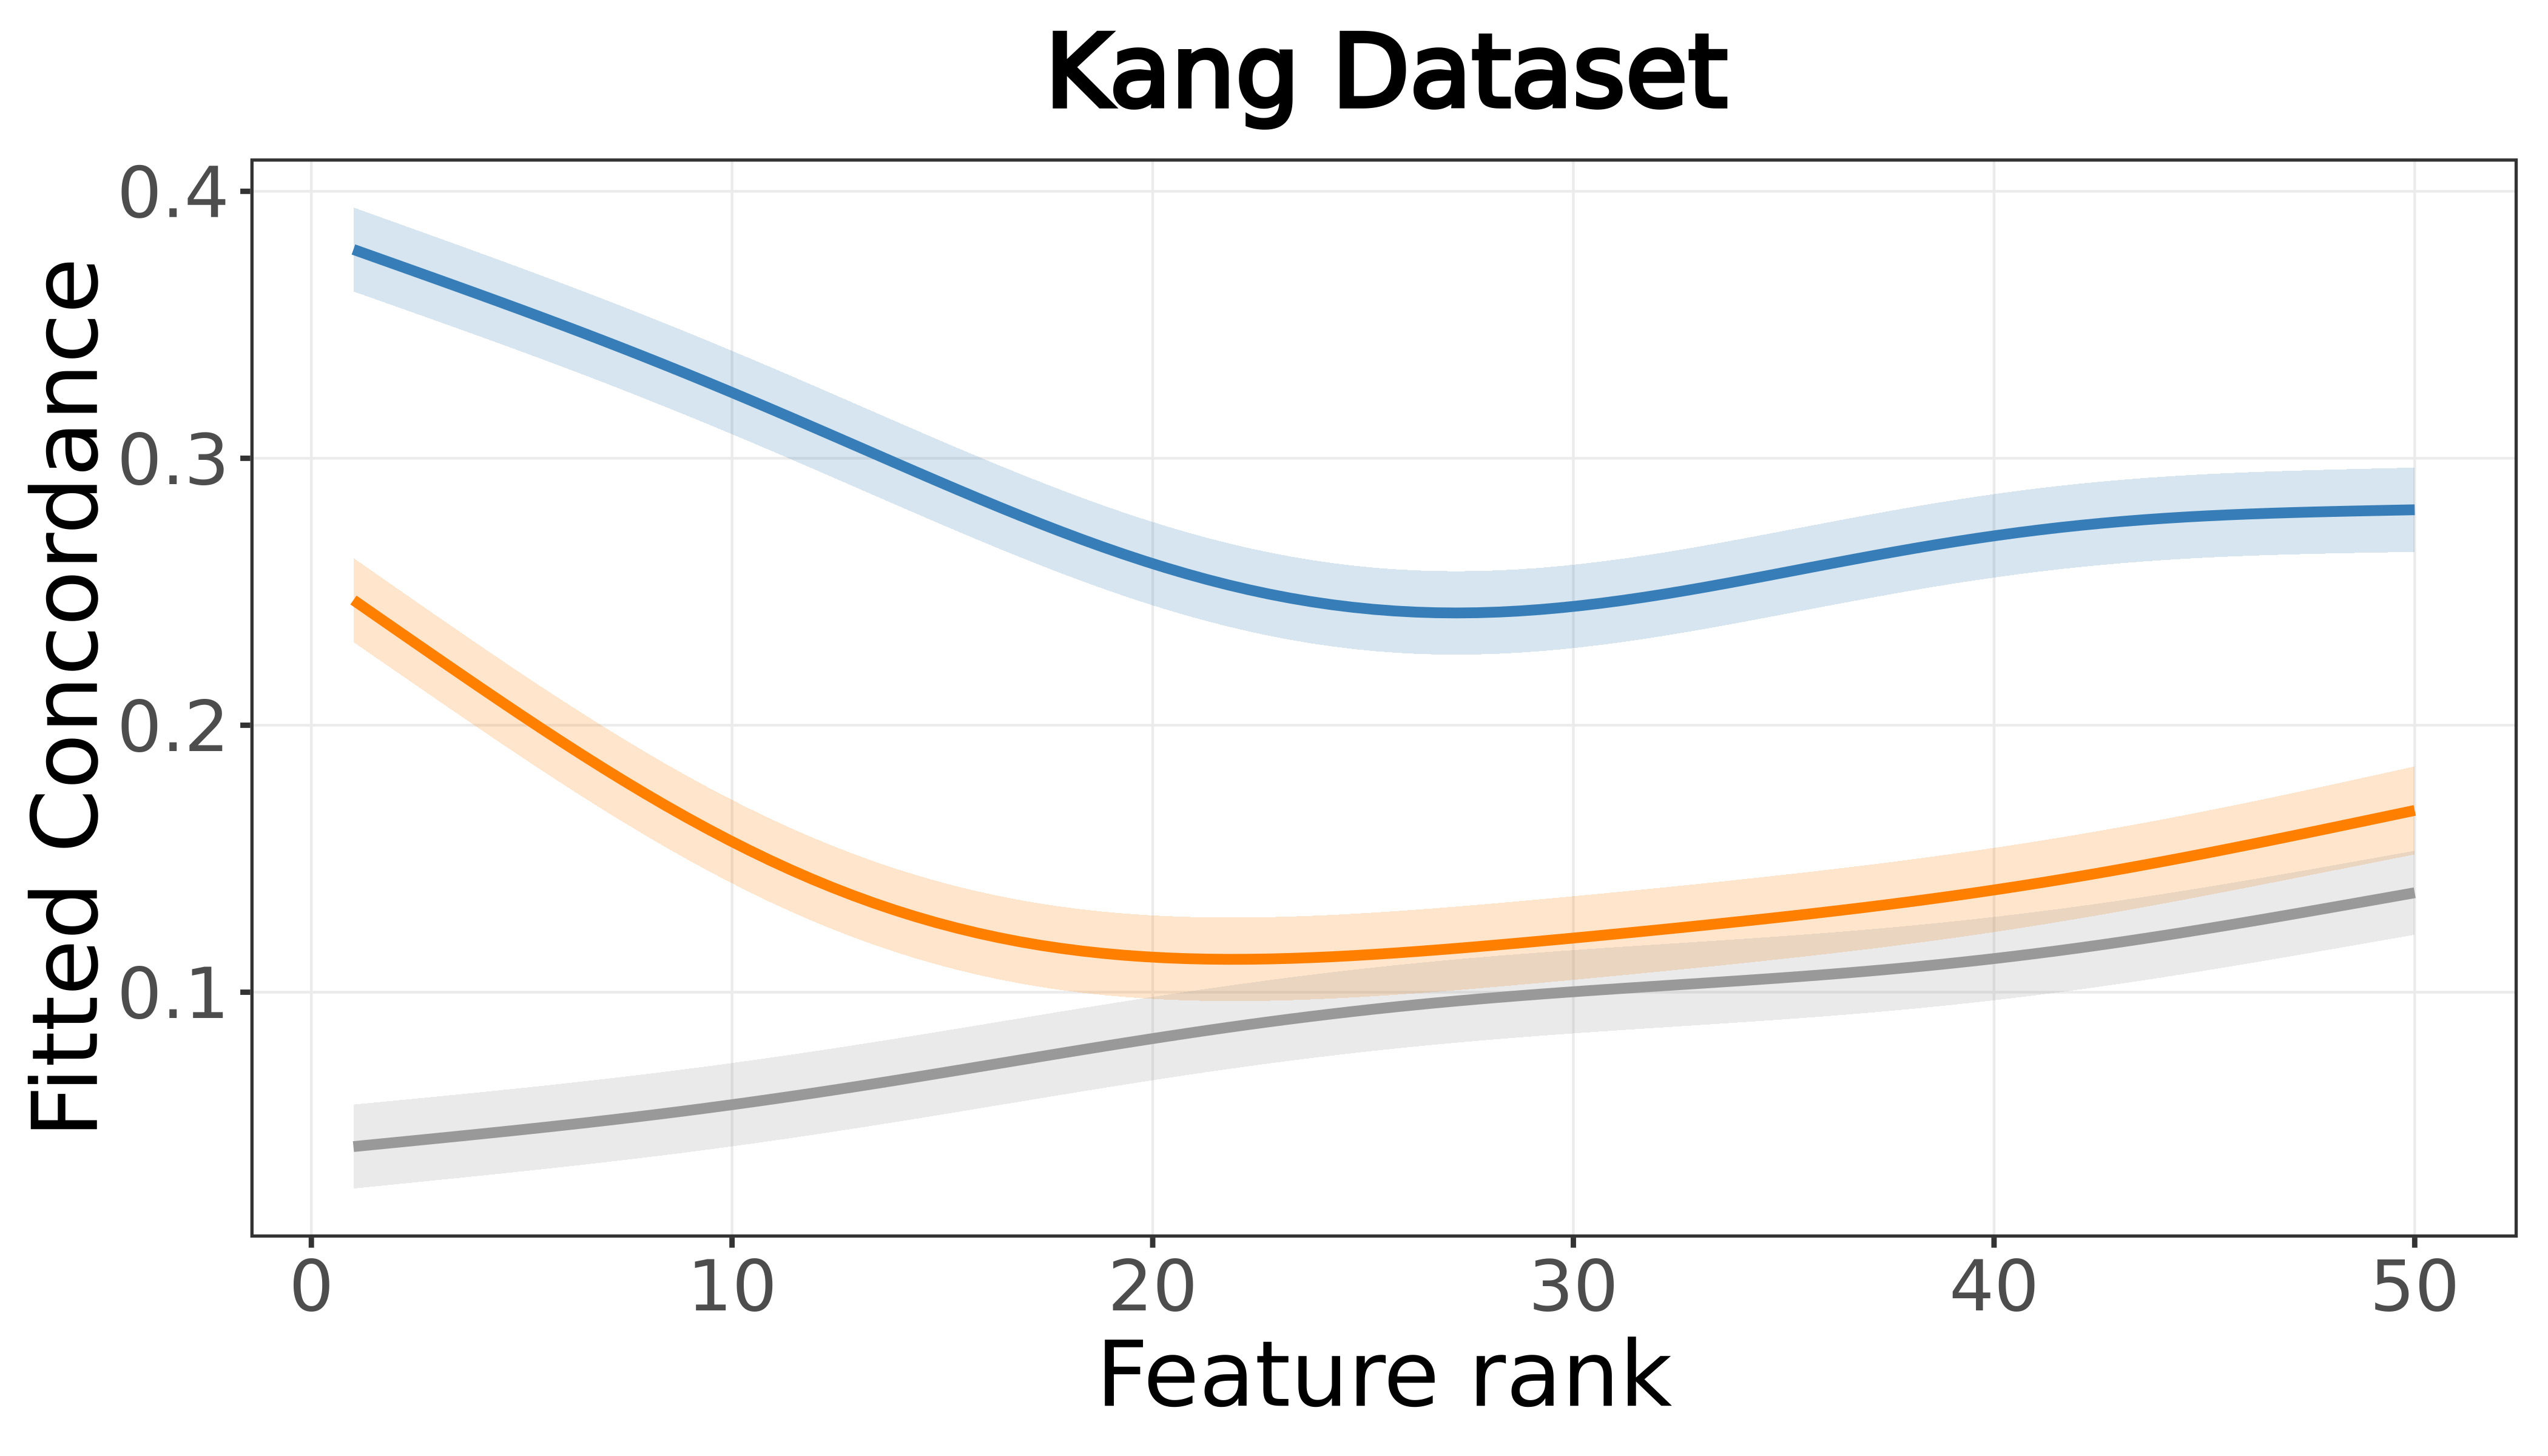

In [23]:
rank_grid <- seq(
  min(concordance_df$rank),
  max(concordance_df$rank),
  length.out = 100
)

# Exclude random-effect smooths for population-level curves
exclude_re <- c("s(test_condition)", "s(subsample_iteration)")

# Direction weights: empirical marginalization
w_dir <- prop.table(table(concordance_df$direction))
dir_levels <- names(w_dir)

# Helper to build a "held values" base row for other covariates
hold_one <- function(df, exclude_names) {
  out <- list()

  for (nm in setdiff(names(df), exclude_names)) {
    x <- df[[nm]]

    if (is.factor(x)) {
      out[[nm]] <- levels(x)[1]
    } else if (is.character(x)) {
      out[[nm]] <- sort(unique(x))[1]
    } else if (is.numeric(x) || is.integer(x)) {
      out[[nm]] <- stats::median(x, na.rm = TRUE)
    } else {
      out[[nm]] <- x[which(!is.na(x))[1]]
    }
  }

  out
}

hold_vals <- hold_one(
  concordance_df,
  exclude_names = c("rank", "mod_type", "direction")
)

# Create fitted curves for each mod_type, marginalized over direction
mods <- levels(concordance_df$mod_type)

all_curves <- lapply(mods, function(m) {

  # Build weighted design matrix across directions:
  # Xbar = sum_d w_d * X(d, mod = m)
  Xbar <- NULL

  for (d in dir_levels) {
    nd <- data.frame(rank = rank_grid)

    nd$mod_type <- factor(m, levels = mods)
    nd$direction <- factor(d, levels = levels(concordance_df$direction))

    # Add held covariates with correct types
    for (nm in names(hold_vals)) {
      val <- hold_vals[[nm]]

      if (is.factor(concordance_df[[nm]])) {
        nd[[nm]] <- factor(val, levels = levels(concordance_df[[nm]]))
      } else if (is.integer(concordance_df[[nm]])) {
        nd[[nm]] <- as.integer(val)
      } else if (is.numeric(concordance_df[[nm]])) {
        nd[[nm]] <- as.numeric(val)
      } else {
        nd[[nm]] <- val
      }
    }

    Xd <- predict(
      model,
      newdata = nd,
      type = "lpmatrix",
      exclude = exclude_re
    )

    Xd <- Xd * as.numeric(w_dir[d])
    Xbar <- if (is.null(Xbar)) Xd else Xbar + Xd
  }

  beta <- coef(model)
  V <- vcov(model)

  fit <- drop(Xbar %*% beta)
  se <- sqrt(rowSums((Xbar %*% V) * Xbar))

  data.frame(
    rank = rank_grid,
    mod_type = m,
    fit = fit,
    lwr = fit - 1.96 * se,
    upr = fit + 1.96 * se
  )
})

plot_df <- do.call(rbind, all_curves)

# Base plot
p_conc <- ggplot(plot_df, aes(x = rank, y = fit, color = mod_type, fill = mod_type)) +
  geom_ribbon(aes(ymin = lwr, ymax = upr), alpha = 0.2, color = NA) +
  geom_line(linewidth = 1) +
  labs(x = "Feature rank", y = "Fitted Concordance") +
  ggtitle("Kang Dataset") +
  theme_pub_bw(show_legend = TRUE)

# Apply exact formatting
p_conc <- p_conc +
  scale_color_manual(
    values = c(
      actual = "#377eb8",  # Set1 blue
      noadv  = "#ff7f00",  # Set1 orange
      random = "#999999"   # gray
    ),
    breaks = c("actual", "noadv", "random"),
    labels = c(
      actual = "Actual",
      noadv  = "No adversarial removal",
      random = "Random"
    )
  ) +
  scale_fill_manual(
    values = c(
      actual = "#377eb8",  # Set1 blue
      noadv  = "#ff7f00",  # Set1 orange
      random = "#999999"   # gray
    ),
    guide = "none"
  ) +
  labs(color = "Model Type") +
  guides(
    color = guide_legend(
      keywidth = unit(1.4, "cm"),
      keyheight = unit(0.6, "cm"),
      override.aes = list(linewidth = 1.5)
    )
  ) +
  theme(
    legend.position = c(0.04, 0.03),
    legend.justification = c(0, 0),

    legend.background = element_rect(
      fill = "white",
      color = "grey",
      linewidth = 0.4
    ),

    legend.margin = margin(6, 24, 6, 10),
    legend.box.margin = margin(4, 4, 4, 4),

    legend.key = element_rect(fill = NA, color = NA),

    legend.title = element_text(size = 20),
    legend.text = element_text(
      size = 18,
      margin = margin(l = 10, r = 10)
    ),
        axis.text = element_text(size = 14), 
        axis.title = element_text(size = 18), 
         plot.title = element_text(
              size = 20,
              face = "bold"
            )
  )

plot_width  <- 7
plot_height <- 4

options(
  repr.plot.width = plot_width,
  repr.plot.height = plot_height,
  repr.plot.res = 600
)

p_conc <- p_conc +
  theme(
    legend.position = "none"
  )

p_conc

ggsave(
  filename = file.path(data_path, 'figures', 'Kang_GAMM_main.png'),
  plot = p_conc,
  width = plot_width,
  height = plot_height,
  dpi = 600
)

Ignoring unknown labels:
• colour : ""
Ignoring unknown labels:
• colour : ""


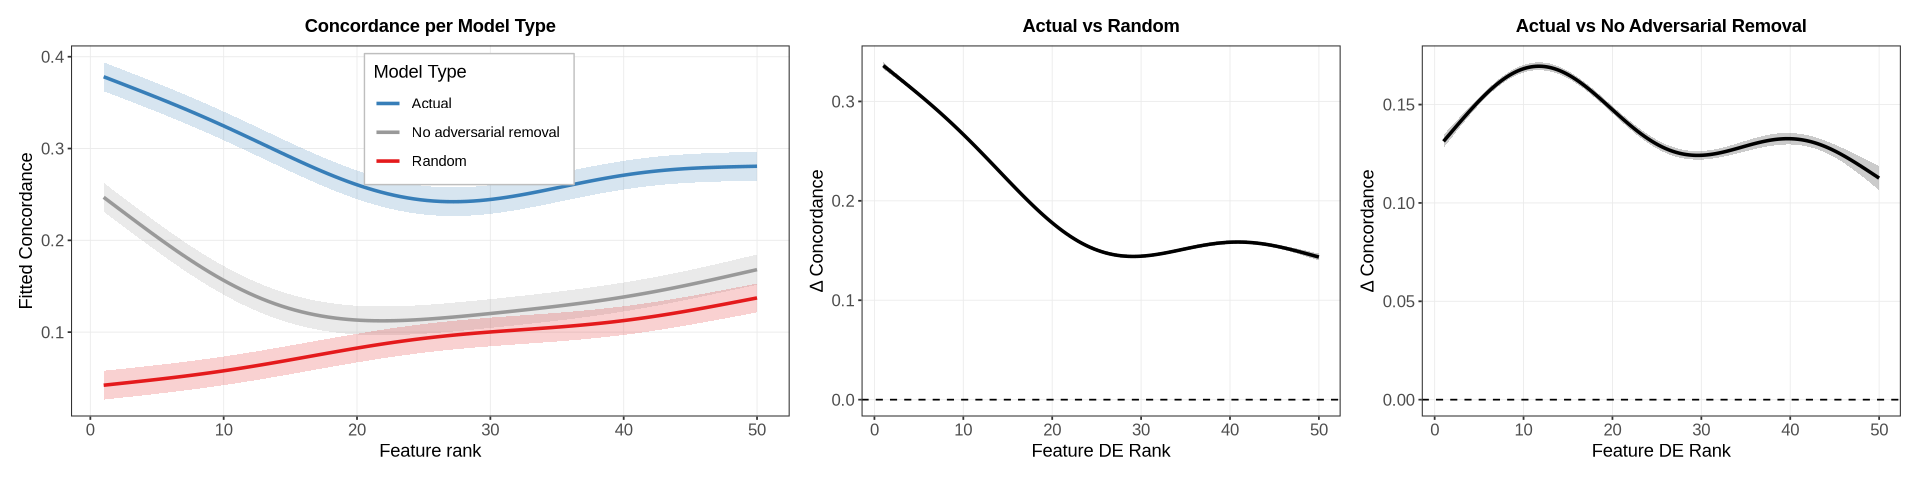

In [47]:
h = 4
w = 16
options(
  repr.plot.width  = w,
  repr.plot.height = h
)

p_all <- (p_conc | p_AR | p_AN) +
  plot_layout(widths = c(1.5, 1, 1))

p_all